In [13]:
import json
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter

In [14]:
data = []
with open('messages.json', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            obj = json.loads(line)
            data.append(obj)

transaction_ids = []
timestamps = []
customer_ids = []
merchant_ids = []
merchant_categories = []
payment_methods = []
amounts = []
locations = []
device_infos = []
statuses = []
commissions_type = []
commission_amounts = []
vat_amounts = []
total_amounts = []
customers_type = []
risk_levels = []
failure_reasons = []


In [15]:
for item in data:
    transaction_ids.append(item['transaction_id']) 
for item in data:
    timestamps.append(item['timestamp']) 
for item in data:
    customer_ids.append(item['customer_id']) 
for item in data:
    merchant_ids.append(item['merchant_id']) 
for item in data:
    merchant_categories.append(item['merchant_category']) 
for item in data:
    payment_methods.append(item['payment_method']) 
for item in data:
    amounts.append(item['amount']) 
for item in data:
    locations.append(item['location']) 
for item in data:
    device_infos.append(item['device_info']) 
for item in data:
    statuses.append(item['status']) 
for item in data:
    commissions_type.append(item['commission_type']) 
for item in data:
    commission_amounts.append(item['commission_amount']) 
for item in data:
    vat_amounts.append(item['vat_amount']) 
for item in data:
    total_amounts.append(item['total_amount']) 
for item in data:
    customers_type.append(item['customer_type'])
for item in data:
    risk_levels.append(item['risk_level'])
for item in data:
    failure_reasons.append(item['failure_reason'])

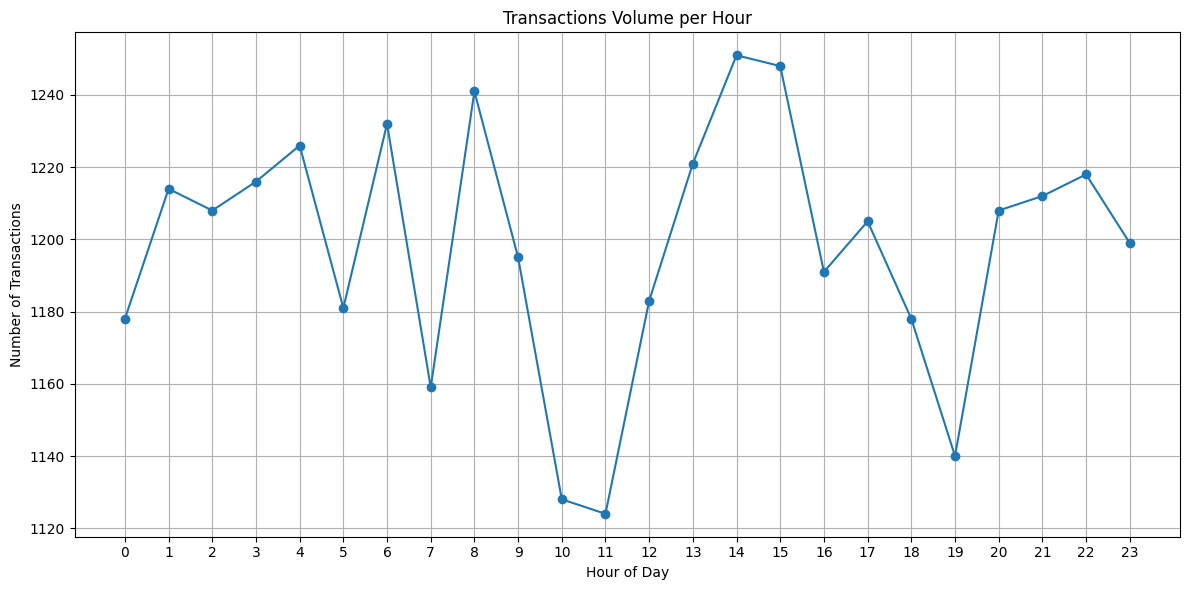

In [16]:
hours = []
for ts in timestamps:
    for i in range(len(ts)):
        if ts[i] == 'T':
            h = int(ts[i + 1] + ts[i + 2])
    hours.append(h)
counter = Counter(hours)

transaction_counts = []
for h in range(24):
    transaction_counts.append(counter.get(h, 0))

plt.figure(figsize=(12,6))
plt.plot(range(24), transaction_counts, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transactions Volume per Hour')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()


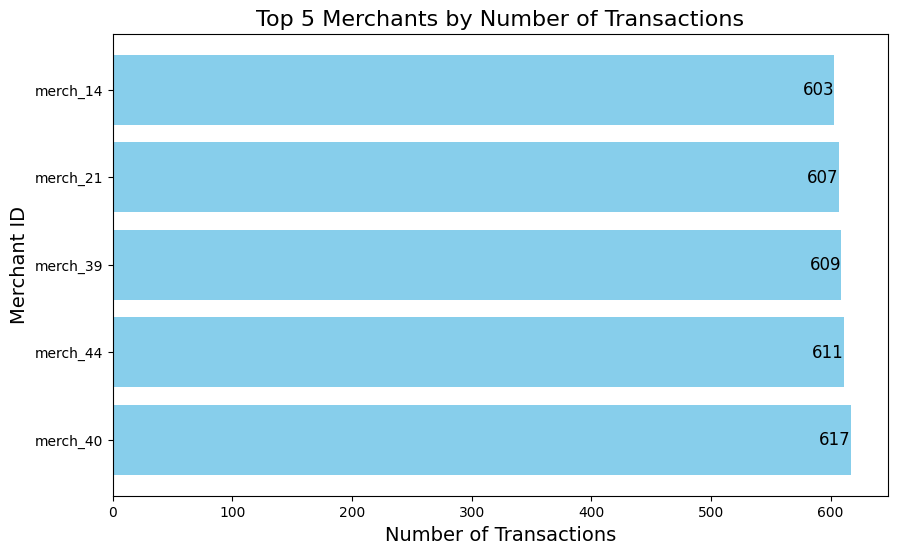

In [17]:
merchant_counts = Counter(merchant_ids)
top_5_merchants = merchant_counts.most_common(5)
merchants = []
transaction_counts = []
for merchant, count in top_5_merchants:
    merchants.append(merchant)
    transaction_counts.append(count)

plt.figure(figsize=(10, 6))
bars = plt.barh(merchants, transaction_counts, color='skyblue')
for bar in bars:
    plt.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2, 
             str(bar.get_width()), va='center', ha='right', fontsize=12, color='black')
plt.xlabel('Number of Transactions', fontsize=14)
plt.ylabel('Merchant ID', fontsize=14)
plt.title('Top 5 Merchants by Number of Transactions', fontsize=16)
plt.show()


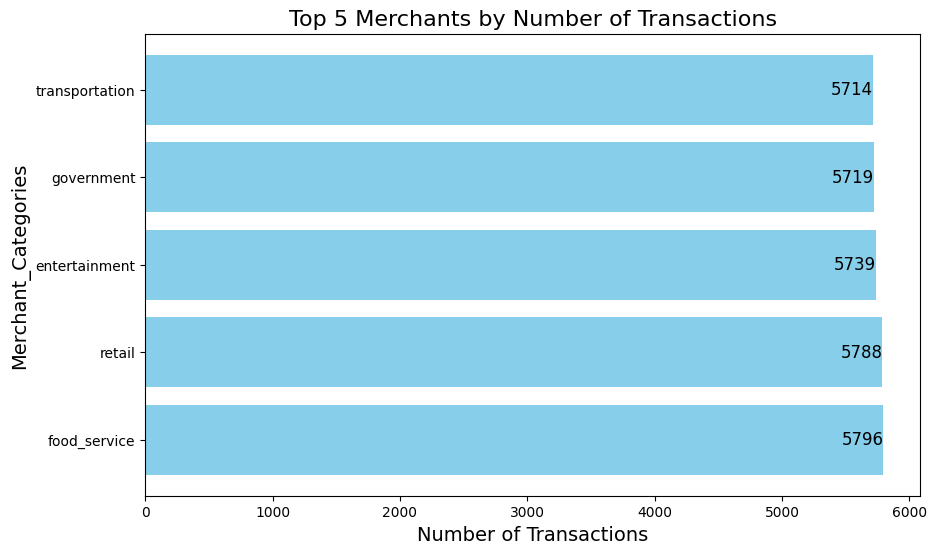

In [18]:
merchant_counts = Counter(merchant_categories)
top_5_merchants = merchant_counts.most_common(5)
merchants = []
transaction_counts = []
for merchant, count in top_5_merchants:
    merchants.append(merchant)
    transaction_counts.append(count)

plt.figure(figsize=(10, 6))
bars = plt.barh(merchants, transaction_counts, color='skyblue')
for bar in bars:
    plt.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2, 
             str(bar.get_width()), va='center', ha='right', fontsize=12, color='black')
plt.xlabel('Number of Transactions', fontsize=14)
plt.ylabel('Merchant_Categories', fontsize=14)
plt.title('Top 5 Merchants by Number of Transactions', fontsize=16)
plt.show()

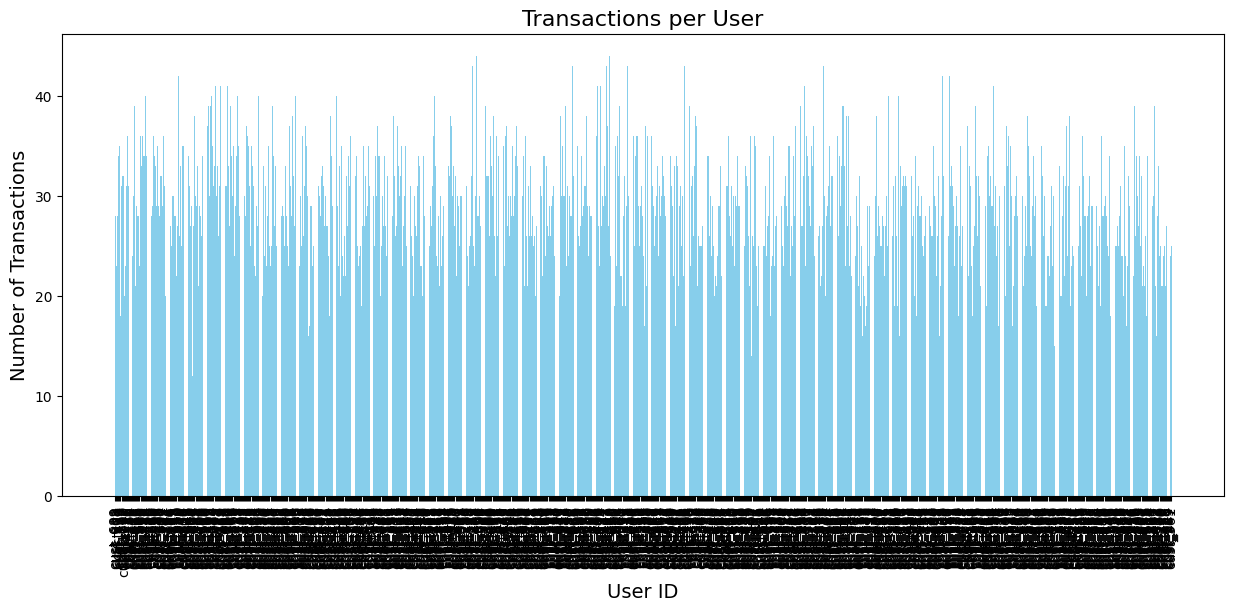

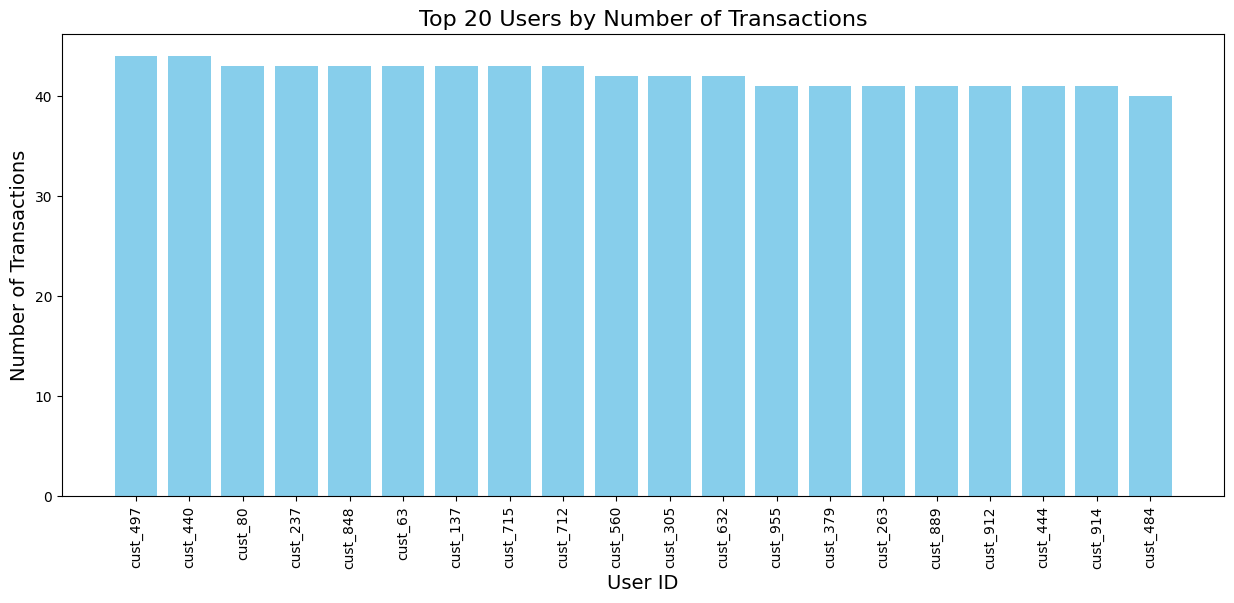

In [19]:
user_transaction_counts = Counter(customer_ids)
users = list(user_transaction_counts.keys())
transaction_counts = list(user_transaction_counts.values())
plt.figure(figsize=(15, 6))
plt.bar(users, transaction_counts, color='skyblue')
plt.xlabel('User ID', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.title('Transactions per User', fontsize=16)
plt.xticks(rotation=90)
plt.show()
user_transaction_counts = Counter(customer_ids)
top_20_users = user_transaction_counts.most_common(20)
users = [user[0] for user in top_20_users]
transaction_counts = [user[1] for user in top_20_users]
plt.figure(figsize=(15, 6))
plt.bar(users, transaction_counts, color='skyblue')
plt.xlabel('User ID', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.title('Top 20 Users by Number of Transactions', fontsize=16)
plt.xticks(rotation=90)
plt.show()


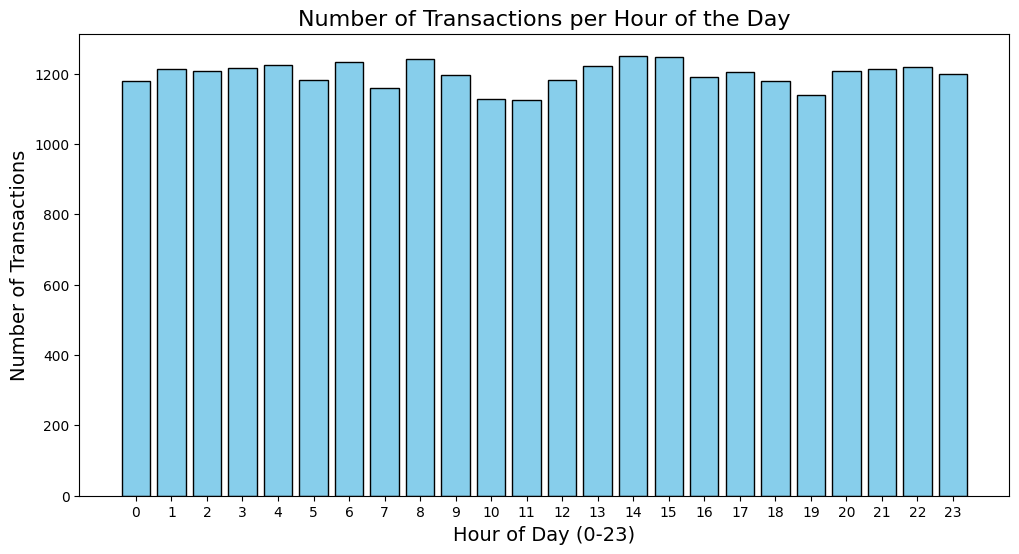

In [20]:
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt
timestamps = [datetime.strptime(timestamp, '%Y-%m-%dT%H:%M:%S.%fZ') for timestamp in timestamps]

hours = [timestamp.hour for timestamp in timestamps]

hourly_activity_counts = Counter(hours)

transaction_counts_per_hour = [hourly_activity_counts.get(hour, 0) for hour in range(24)]

plt.figure(figsize=(12, 6))
plt.bar(range(24), transaction_counts_per_hour, color='skyblue', edgecolor='black')
plt.xlabel('Hour of Day (0-23)', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.title('Number of Transactions per Hour of the Day', fontsize=16)
plt.xticks(range(24)) 
plt.show()


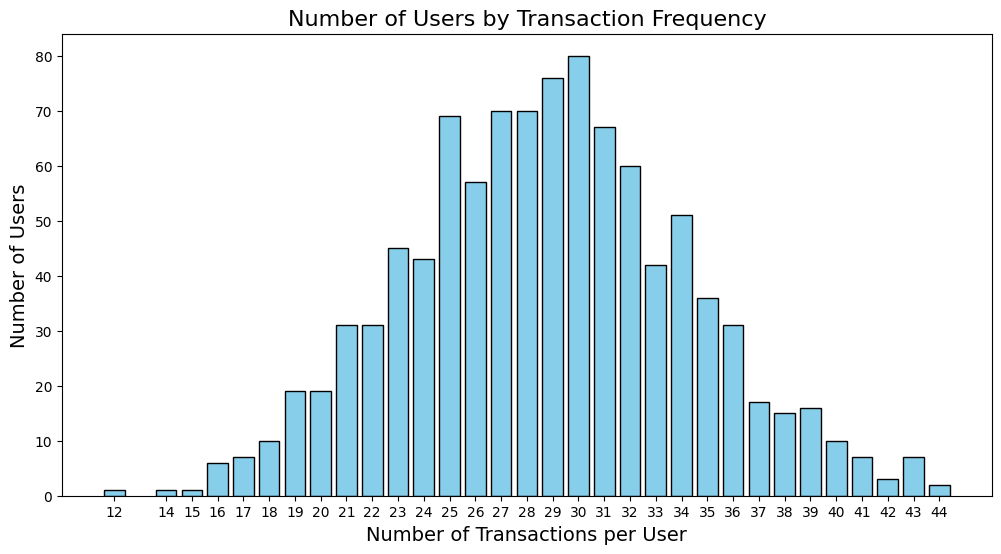

In [21]:
user_transaction_counts = Counter(customer_ids)
transaction_count_frequency = Counter(user_transaction_counts.values())
transaction_counts = list(transaction_count_frequency.keys())
user_counts = list(transaction_count_frequency.values())
plt.figure(figsize=(12, 6))
plt.bar(transaction_counts, user_counts, color='skyblue', edgecolor='black')
plt.xlabel('Number of Transactions per User', fontsize=14)
plt.ylabel('Number of Users', fontsize=14)
plt.title('Number of Users by Transaction Frequency', fontsize=16)
plt.xticks(transaction_counts)
plt.show()
